# 本节操作-线性代数

In [1]:
import torch

C:\Users\XianZS\.conda\envs\dl2_env\lib\site-packages\torch\torch_version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


## 标量

In [2]:
# 标量指的是一个数值的张量
x = torch.tensor(3.0)
y = torch.tensor(2.0)
x, y, x + y, x * y, x / y, x - y, x ** y

(tensor(3.),
 tensor(2.),
 tensor(5.),
 tensor(6.),
 tensor(1.5000),
 tensor(1.),
 tensor(9.))

In [3]:
## 张量
x = torch.arange(4)
x, x[1], x[2], x[3], x[0]

(tensor([0, 1, 2, 3]), tensor(1), tensor(2), tensor(3), tensor(0))

## 长度、尺寸和形状

In [4]:
len(x), x.shape, torch.Size(x)

(4, torch.Size([4]), torch.Size([0, 1, 2, 3]))

## 矩阵

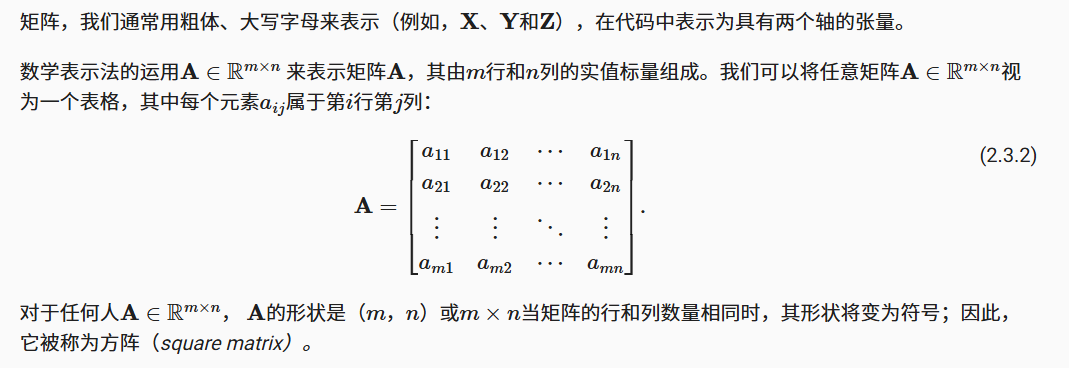



In [5]:
A = torch.arange(20).reshape(4, 5)
A, A[0, 2], A[0][2]

(tensor([[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9],
         [10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]]),
 tensor(2),
 tensor(2))

In [6]:
# 矩阵的转置运算
A.T

tensor([[ 0,  5, 10, 15],
        [ 1,  6, 11, 16],
        [ 2,  7, 12, 17],
        [ 3,  8, 13, 18],
        [ 4,  9, 14, 19]])

## 张量

In [7]:
# 张量的简单使用
B = torch.arange(20).reshape(2, 2, 5)
B

tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]]])

标量、向量、矩阵和任意数量轴的张量（本小节中的“张量”指代数对象）有一些实用的属性。例如，从按元素操作的定义中注意，任何元素的一元损害都不会改变其操作数的形状。同样，给定具有相同形状的任意两个张量，任何按元素二元危害的结果都将是相同形状的张量。例如，将两个相同形状的矩阵相加，会在这两个矩阵上执行元素加法。

In [8]:
A = torch.arange(20, dtype=torch.float).reshape(2, 2, 5)
# 通过分配新内存，将A的一个副本分配给B
B = A.clone()
print(id(A), id(B))
print(A + B)

2156756503904 2156889893120
tensor([[[ 0.,  2.,  4.,  6.,  8.],
         [10., 12., 14., 16., 18.]],

        [[20., 22., 24., 26., 28.],
         [30., 32., 34., 36., 38.]]])


In [9]:
# 矩阵的积运算
print(A * B)
# 张量和标量之间的运算
print(A * 2)

tensor([[[  0.,   1.,   4.,   9.,  16.],
         [ 25.,  36.,  49.,  64.,  81.]],

        [[100., 121., 144., 169., 196.],
         [225., 256., 289., 324., 361.]]])
tensor([[[ 0.,  2.,  4.,  6.,  8.],
         [10., 12., 14., 16., 18.]],

        [[20., 22., 24., 26., 28.],
         [30., 32., 34., 36., 38.]]])


## 降低维度

In [10]:
x = torch.arange(4, dtype=torch.float)
x, x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

In [11]:
# 假设创建一个二维矩阵张量Z
Z = torch.arange(12).reshape(3, 4)
Z, Z.shape,Z.sum()

(tensor([[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]]),
 torch.Size([3, 4]),
 tensor(66))

In [12]:
# 但是我可以先按照行或者列进行求和
# 将所有的结果全部降维成一行，也就是将所有的内部元素按照列进行求和
Z1=Z.sum(axis=0)
# 将所有的结果全部降维成一列，也就是将所有的内部元素按照行进行求和
Z2=Z.sum(axis=1)
Z1,Z2

(tensor([12, 15, 18, 21]), tensor([ 6, 22, 38]))

In [13]:
# 通过平均值来进行降维
Z.sum(),Z.numel(),Z.sum()/Z.numel(),Z.sum(axis=0)/Z.shape[0]

(tensor(66), 12, tensor(5.5000), tensor([4., 5., 6., 7.]))

## 非降维求和

In [14]:
# 首先，需要说明的是，在进行降维求和时，最好保持数轴不变，这样更加直观
A=torch.arange(20).reshape(4,5)
A1=A.sum(axis=1)
# 推荐设置keepdim=True
A2=A.sum(axis=1,keepdim=True)
A1,A2

(tensor([10, 35, 60, 85]),
 tensor([[10],
         [35],
         [60],
         [85]]))

In [15]:
# 非降维求和之后，我们可以直接进行元素级的除法运算，来得到归一化后的张量
A/A2

tensor([[0.0000, 0.1000, 0.2000, 0.3000, 0.4000],
        [0.1429, 0.1714, 0.2000, 0.2286, 0.2571],
        [0.1667, 0.1833, 0.2000, 0.2167, 0.2333],
        [0.1765, 0.1882, 0.2000, 0.2118, 0.2235]])

In [16]:
# 如果我们想沿某个轴计算A元素的累积总和
A.cumsum(axis=0)

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  7,  9, 11, 13],
        [15, 18, 21, 24, 27],
        [30, 34, 38, 42, 46]])